In [ ]:
!pip install sqlalchemy-iris
!pip install drawdata

In [ ]:
from datetime import datetime
from drawdata import ScatterWidget
from sqlalchemy import create_engine
import dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import iris
import json

dotenv.load_dotenv()

connection_params = {
    "hostname": os.getenv("IRIS_SERVER"),
    "port": int(os.getenv("IRIS_PORT")),
    "namespace": os.getenv("IRIS_NAMESPACE"),
    "username": os.getenv("IRIS_USERNAME"),
    "password": os.getenv("IRIS_PASSWORD")
}

### Create Points

In [4]:
widget = ScatterWidget(height=200, width=200)
widget

In [137]:
df = widget.data_as_pandas[["x", "y", "label"]]
datetime_now = datetime.now()
df["datetime"] = datetime_now
df.head()

,x,y,label,datetime
0,20.996820,107.141927,a,2026-03-20 15:40:21.829482
1,32.774149,109.048787,a,2026-03-20 15:40:21.829482
2,29.944813,108.618423,a,2026-03-20 15:40:21.829482
3,36.809775,102.640871,a,2026-03-20 15:40:21.829482
4,41.730020,109.175278,a,2026-03-20 15:40:21.829482


In [138]:
engine = create_engine(f"iris://{connection_params['username']}:{connection_params['password']}@{connection_params['hostname']}:{connection_params['port']}/{connection_params['namespace']}")
df.to_sql("PointSamples", engine, schema="MLpipeline", if_exists='append', index=False, method='multi')

-1

### Prediction Testing

Mean Absolute Error: 2.9802
R^2 Score: 0.1540


C:\Users\jjaramil\AppData\Local\Temp\ipykernel_7984\2823424618.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.x, df.y, cmap='viridis', label='Data Points')


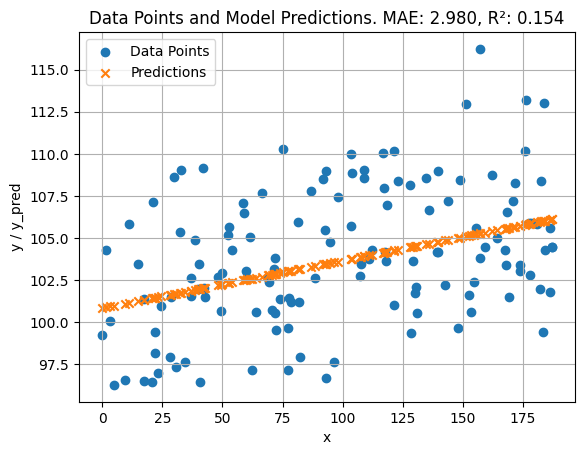

In [ ]:
date_filter = f"datetime >= '{datetime_now}'" # MODIFY AS DESIRED
with iris.connect(**connection_params) as conn:
    iris_obj = iris.createIRIS(conn)
    json_result  = iris_obj.classMethodValue("MLpipeline.PredictionService", "Predict", date_filter)
    predictions = json.loads(json_result)

# PLOT OF RESULTS JUST GOT FROM IRIS
mae = mean_absolute_error(df.y, predictions)
r2 = r2_score(df.y, predictions)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

plt.Figure(figsize=(10,10))
plt.scatter(df.x, df.y, cmap='viridis', label='Data Points')
plt.scatter(df.x, predictions, marker='x', label='Predictions')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.xlabel('x')
plt.ylabel('y / y_pred')
plt.title(f'Data Points and Model Predictions. MAE: {mae:.3f}, R²: {r2:.3f}')
plt.legend()
plt.grid()
plt.show()

### Monitoring Tesing

In [140]:
with iris.connect(**connection_params) as conn:
    iris_obj = iris.createIRIS(conn)
    PM = iris_obj.classMethodObject("MLpipeline.PerformanceMonitoring", "%New")
    status = PM.invoke("MetricsMonitoring",datetime_now.strftime("%Y-%m-%d %H:%M:%S"))
print(f"Performance monitoring status: {status}")

🏃 View run skillful-wolf-541 at: http://mlflow:5000/#/experiments/6/runs/8f07e591883b466cb38dacc9d2b51590
🧪 View experiment at: http://mlflow:5000/#/experiments/6
🏃 View run skillful-wolf-541 at: http://mlflow:5000/#/experiments/6/runs/8f07e591883b466cb38dacc9d2b51590
🧪 View experiment at: http://mlflow:5000/#/experiments/6
minr2threshold: 0.2
Performance degradation detected! R2 score -142.88305113330028 is below the threshold of 0.2. RETRAINING...
🏃 View run victorious-skunk-862 at: http://mlflow:5000/#/experiments/7/runs/3d83a90ed72144dbb2c69bed4b0c3b74
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run victorious-skunk-862 at: http://mlflow:5000/#/experiments/7/runs/3d83a90ed72144dbb2c69bed4b0c3b74
🧪 View experiment at: http://mlflow:5000/#/experiments/7
🏃 View run victorious-skunk-862 at: http://mlflow:5000/#/experiments/7/runs/3d83a90ed72144dbb2c69bed4b0c3b74
🧪 View experiment at: http://mlflow:5000/#/experiments/7
Retraining pipeline triggered. Summary: {'MLFLOW